# Comparing $\mu_c$ estimators — improved run

Same two estimators as before (the shape scalar $c$ and the $t_\text{final}$ drop, both read
off one integration), with three improvements over the first notebook:

1. **Event-based $M$ cap.** The solver halts when $M$ reaches `M_CAP` (well below
   floating-point overflow), so supercritical runs return *valid* values instead of `NaN`.
   This fills the gaps that appeared in the earlier sweeps and lets us push $\tau_{max}$ high.
2. **More realizations** ($\sim$20 seeds) — tighter error bars, so bias becomes visible.
3. **$\tau_{max}$ up to $10^6$** — settles whether the $t_\text{final}$ estimate is still
   drifting or has converged.

Recall $c \equiv (y^*)^\top W y^* - (y^*)^\top y^*$ sets the sign of $dM/d\tau = 1 + cM$:
$M$ plateaus at $-1/c$ when $c<0$ ($\mu<\mu_c$) and grows like $e^{c\tau}$ when $c>0$
($\mu>\mu_c$). Above threshold $t_\text{final}=\int d\tau/M$ has already converged to $t^*$
by the time $M$ hits the cap, and $c$ already has its sign — so capping costs no accuracy.

## 1. Setup

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import time as _time

N, C, SIGMA = 1000, 50, 0.2
RTOL, ATOL, MAX_STEP = 1e-8, 1e-10, 1e3
M_CAP = 1e250        # halt integration when M reaches this (overflow ~1e308)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## 2. Network: configuration model with frozen disorder

`build_graph` fixes topology + the Gaussian disorder $z_{ij}$ for a seed; `make_W` dials in
$\mu$ without regenerating either, so a $\mu$-sweep moves along one fixed realization.

In [4]:
def build_graph(N, C, seed):
    """Configuration-model graph (exponential degrees, mean C) + frozen disorder z_ij."""
    r = np.random.default_rng(seed)
    degs = np.maximum(1, np.round(r.exponential(C, N))).astype(int)
    if degs.sum() % 2:
        degs[0] += 1
    stubs = np.repeat(np.arange(N), degs); r.shuffle(stubs)
    e1, e2 = stubs[0::2], stubs[1::2]
    keep = e1 != e2
    e1, e2 = e1[keep], e2[keep]
    rows = np.concatenate([e1, e2]); cols = np.concatenate([e2, e1])
    A = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A.data[:] = 1.0
    A = A.tolil(); A.setdiag(0); A = A.tocsr(); A.eliminate_zeros()
    coo = A.tocoo()
    z = np.random.default_rng(seed + 999).standard_normal(coo.nnz)
    return A, coo.row, coo.col, z

def make_W(rows, cols, z, mu, C, shape):
    return sp.csr_matrix((mu / C + (SIGMA / np.sqrt(C)) * z, (rows, cols)), shape=shape)

A, rows, cols, z = build_graph(N, C, seed=1)
g = np.asarray(A.sum(1)).ravel()
print(f"realized mean degree = {g.mean():.1f},  <g^2> = {(g**2).mean():.0f}")

realized mean degree = 45.8,  <g^2> = 3909


## 3. Integrator with $M$ cap

The event `cap` triggers when $M$ crosses `M_CAP`; `terminal=True` stops the solve there.
`solve_ivp` still reports `success=True` for an event stop, so both observables are read off
the final state regardless of whether the run reached $\tau_{max}$ or hit the cap first.

In [5]:

def rhs_factory(W, N):
    def rhs(tau, s):
        y = s[:N]; M = s[N]
        y = np.clip(y, 0.0, None)
        ssum = y.sum()
        if ssum > 0:
            y = y / ssum
        F = W @ y; phi = y @ F; sq = y @ y
        dy = y * (F - phi - y + sq)
        dM = 0.0 if M >= M_CAP else 1.0 + M * (phi - sq)   # freeze at cap, never overflow
        dt = 1.0 / M
        return np.concatenate([dy, [dM], [dt]])
    return rhs


def integrate(W, N, tau_max):
    rhs = rhs_factory(W, N)
    s0 = np.concatenate([np.full(N, 1.0 / N), [1.0], [0.0]])
    def cap(tau, s):
        return s[N] - M_CAP
    cap.terminal = True; cap.direction = 1
    sol = solve_ivp(rhs, (0.0, tau_max), s0, method="LSODA",
                    rtol=RTOL, atol=ATOL, max_step=MAX_STEP,
                    events=cap, dense_output=False,
                    t_eval=[tau_max])

    # pick the final state: from the event if the cap fired, else from sol.y
    if sol.t_events[0].size > 0:
        final = np.asarray(sol.y_events[0])[-1]      # event state(s): shape (k, N+2)
    else:
        y_arr = np.asarray(sol.y)                    # shape (N+2, n_eval)
        final = y_arr[:, -1]

    final = np.asarray(final).ravel()                # guarantee 1-D, length N+2
    y = np.clip(final[:N], 0.0, None)
    y = y / y.sum()
    F = W @ y
    return dict(c=float(y @ F - y @ y),
                t_final=float(final[N + 1]),
                M_final=float(final[N]),
                n_steps=int(sol.nfev),
                nfev=int(sol.nfev),
                success=bool(sol.success),
                stopped_early=(sol.status == 1))

## 4. Timing calibration

Run this once to budget the full experiment. Look at the seconds for $\tau_{max}=10^6$:
the main run is `len(SEEDS) * len(TAU_MAXES) * len(mus)` integrations plus Brent refinements,
so if a $10^6$ run is a few seconds, the full sweep can be a couple of hours. Trim `SEEDS`,
`mus`, or the $10^6$ tier if needed. If you see `stopped_early=True`, the cap is doing its job.

In [6]:
A, rows, cols, z = build_graph(N, C, seed=1)
for mu, tm in [(0.45, 1e5), (0.65, 1e5), (0.45, 1e6), (0.65, 1e6)]:
    W = make_W(rows, cols, z, mu, C, A.shape)
    t0 = _time.time(); r = integrate(W, N, tm); dt = _time.time() - t0
    print(f"mu={mu} tau={tm:.0e}: {dt:5.2f}s  steps={r['n_steps']:5d}  "
          f"M_final={r['M_final']:.2e}  c={r['c']:+.5f}  "
          f"early_stop={r['stopped_early']}  ok={r['success']}")

mu=0.45 tau=1e+05:  0.60s  steps=12742  M_final=2.68e+03  c=-0.00037  early_stop=False  ok=True
mu=0.65 tau=1e+05:  0.98s  steps=19140  M_final=1.18e+12  c=+0.00019  early_stop=False  ok=True
mu=0.45 tau=1e+06:  2.72s  steps=58731  M_final=2.68e+03  c=-0.00037  early_stop=False  ok=True
mu=0.65 tau=1e+06:  9.91s  steps=194184  M_final=2.91e+87  c=+0.00019  early_stop=False  ok=True


## 5. Sweep and locators

`locate_c` does a per-realization Brent root-find (grid bracket + refinement, not grid-limited).
`locate_drop` takes the steepest descent of $t_\text{final}(\mu)$.

In [7]:
def sweep(rows, cols, z, shape, mus, tau_max):
    out = {k: [] for k in ["mu", "c", "t_final", "M_final", "n_steps"]}
    for mu in mus:
        W = make_W(rows, cols, z, mu, C, shape)
        r = integrate(W, N, tau_max)
        out["mu"].append(mu)
        for k in ["c", "t_final", "M_final", "n_steps"]:
            out[k].append(r[k] if r["success"] else np.nan)
    return {k: np.array(v) for k, v in out.items()}

def locate_c(rows, cols, z, shape, mus, tau_max, refine_below=2e4):
    """NaN-robust zero-crossing of c(mu). Brent-refine only when integration is
    cheap (tau_max < refine_below); at large tau_max use the grid interpolation,
    whose error is far inside the realization spread and avoids costly stiff
    refinement runs near the critical mu."""
    cs = sweep(rows, cols, z, shape, mus, tau_max)["c"]
    good = np.isfinite(cs)                      # drop failed points
    m, c = mus[good], cs[good]
    sc = np.where(np.diff(np.sign(c)))[0]
    if len(sc) == 0:
        return np.nan
    i = sc[0]
    interp = m[i] - c[i] * (m[i + 1] - m[i]) / (c[i + 1] - c[i])
    if tau_max >= refine_below:
        return interp
    def c_of_mu(mu):
        val = integrate(make_W(rows, cols, z, mu, C, shape), N, tau_max)["c"]
        return val if np.isfinite(val) else np.sign(c[i]) * 1e-12
    try:
        return brentq(c_of_mu, m[i], m[i + 1], xtol=1e-3, maxiter=40)
    except ValueError:
        return interp

def locate_drop(mus, t_final):
    good = np.isfinite(t_final)
    m, t = mus[good], t_final[good]
    return m[np.argmin(np.gradient(t, m))]

## 6. Single sweep at $\tau_{max}=10^6$ (check the gaps are gone)

With the cap in place the supercritical branch should be fully populated. Eyeball this before
trusting the drop locator — a clean, gap-free $t_\text{final}(\mu)$ is what makes
`np.gradient` reliable.

1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
1000000.0
959598.7509686492
808230.028746752
694769.500364456
606919.0349271351
536998.1693586102
c: 0 non-finite (all finite)
t_final: 0 non-finite (all finite)
M_final: 0 non-finite (all finite)


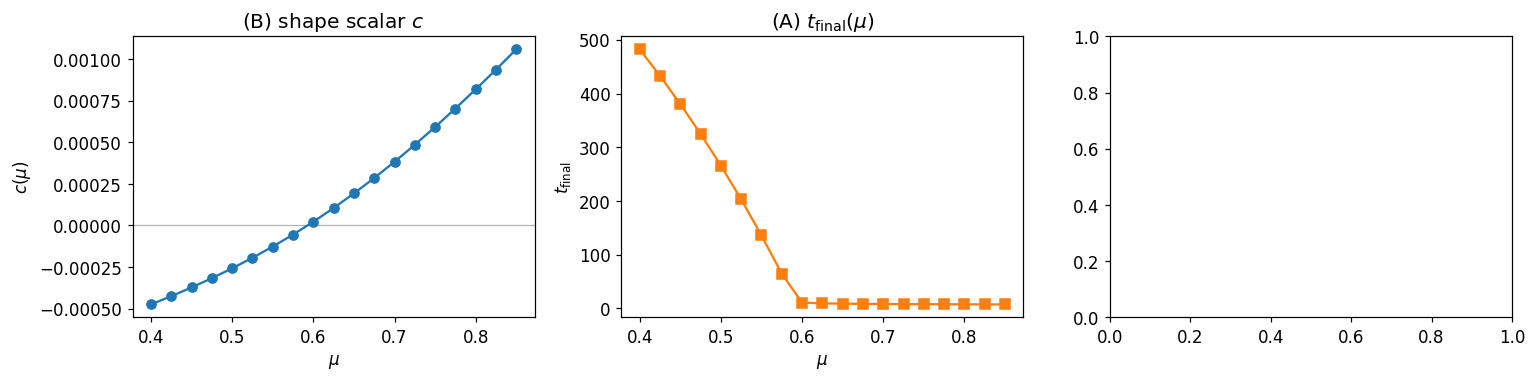

In [36]:
mus = np.linspace(0.40, 0.85, 19)
A, rows, cols, z = build_graph(N, C, seed=1)
S = sweep(rows, cols, z, A.shape, mus, tau_max=1e6)
for k in ["c", "t_final", "M_final"]:
    arr = np.asarray(S[k], dtype=float)
    bad = ~np.isfinite(arr)
    print(f"{k}: {bad.sum()} non-finite", 
          "at mu=" + str(np.asarray(S["mu"])[bad]) if bad.any() else "(all finite)")
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].axhline(0, color="0.7", lw=0.8)
ax[0].plot(S["mu"], S["c"], "o-")
ax[0].set(xlabel=r"$\mu$", ylabel=r"$c(\mu)$", title=r"(B) shape scalar $c$")
# symlog so the tiny negative branch is visible
# ax[0].set_yscale("symlog", linthresh=1e-5)
ax[1].plot(S["mu"], S["t_final"], "s-", color="C1")
ax[1].set(xlabel=r"$\mu$", ylabel=r"$t_{\rm final}$", title=r"(A) $t_{\rm final}(\mu)$")

fig.tight_layout(); plt.show()


## 7. Main experiment: bias & variance vs. $\tau_{max}$

20 realizations, $\tau_{max}$ up to $10^6$. Reduce `SEEDS` or drop the $10^6$ tier if the
calibration above showed it's too slow. The bias question (does $t_\text{final}$ converge to
the reference, or keep climbing toward $c$?) is answered by the $10^5\!\to\!10^6$ move.

In [ ]:
from joblib import Parallel, delayed
import numpy as np

SEEDS     = list(range(1, 6))
TAU_MAXES = [1e3, 1e4, 1e5, 5e5, 1e6, 1.5e6, 2.5e6]
mus       = np.linspace(0.40, 0.85, 19)

# Persistent in-kernel cache keyed by (seed, tau_max). Survives re-running this
# cell, so adding a new tau_max to TAU_MAXES only computes the *new* pairs.
# NOTE: cache assumes mus / N / C / SIGMA are unchanged. If you edit those,
# reset with:  _CACHE = {}
try:
    _CACHE
except NameError:
    _CACHE = {}

def one_task(seed, tm):
    A, rows, cols, z = build_graph(N, C, seed)
    S = sweep(rows, cols, z, A.shape, mus, tm)
    return (seed, tm,
            locate_c(rows, cols, z, A.shape, mus, tm),
            locate_drop(mus, S["t_final"]),
            float(np.nanmean(S["n_steps"])))

todo = [(seed, tm) for seed in SEEDS for tm in TAU_MAXES if (seed, tm) not in _CACHE]
print(f"{len(todo)} new (seed, tau_max) pairs to compute; {len(_CACHE)} already cached")

if todo:
    new = Parallel(n_jobs=-1, verbose=5)(
        delayed(one_task)(seed, tm) for seed, tm in todo
    )
    for seed, tm, c_loc, d_loc, steps in new:
        _CACHE[(seed, tm)] = (c_loc, d_loc, steps)

results = {tm: {"c": [], "drop": [], "steps": []} for tm in TAU_MAXES}
for seed in SEEDS:
    for tm in TAU_MAXES:
        c_loc, d_loc, steps = _CACHE[(seed, tm)]
        results[tm]["c"].append(c_loc)
        results[tm]["drop"].append(d_loc)
        results[tm]["steps"].append(steps)

print("\n=== mu_c estimates (mean +/- std over realizations) ===")
print(f"{'tau_max':>9} | {'c zero-cross':>20} | {'t_final drop':>20} | {'sweep steps':>11}")
for tm in TAU_MAXES:
    c = np.array(results[tm]["c"]); d = np.array(results[tm]["drop"])
    print(f"{tm:9.0e} | {np.nanmean(c):7.4f} +/- {np.nanstd(c):.4f}    "
          f"| {np.nanmean(d):7.4f} +/- {np.nanstd(d):.4f}    "
          f"| {np.mean(results[tm]['steps']):11.0f}")

5 new (seed, tau_max) pairs to compute; 30 already cached


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 12.0min remaining: 17.9min


## 8. Bias plot

Set `MU_C_REF` to your **mean-field** solution of Eq. (2.10) (the `0.57` is a placeholder).
A good estimator is flat in $\tau_{max}$ (insensitive to the cutoff), has small bars (low
realization variance), and sits on the reference line (unbiased).

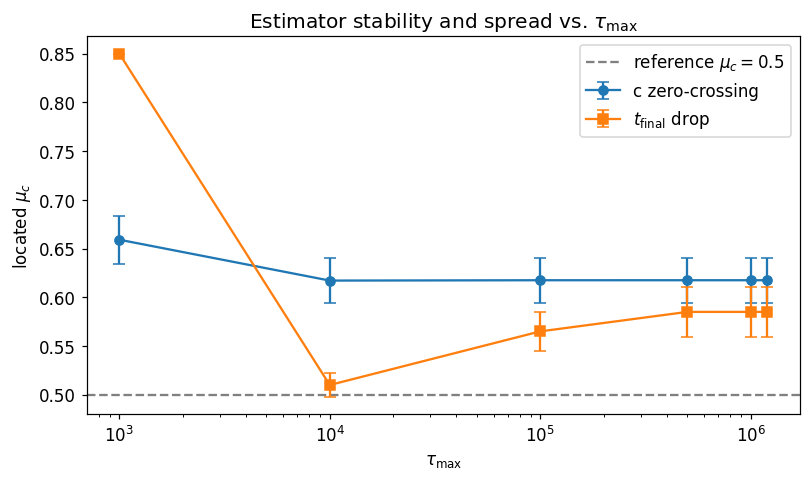

In [46]:
MU_C_REF = 0.5   # <-- replace with your mean-field value

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.axhline(MU_C_REF, color="0.5", ls="--", label=fr"reference $\mu_c={MU_C_REF}$")
for key, lab, off, mk in [("c", "c zero-crossing", 1, "o"),
                          ("drop", r"$t_{\rm final}$ drop", 1, "s")]:
    m = np.array([np.nanmean(results[tm][key]) for tm in TAU_MAXES])
    e = np.array([np.nanstd (results[tm][key]) for tm in TAU_MAXES])
    ax.errorbar(np.array(TAU_MAXES) * off, m, yerr=e, marker=mk, capsize=4, lw=1.5, label=lab)
ax.set_xscale("log")
ax.set(xlabel=r"$\tau_{\max}$", ylabel=r"located $\mu_c$",
       title=r"Estimator stability and spread vs. $\tau_{\max}$")
ax.legend(); fig.tight_layout(); plt.show()

## 9. Read-off

- If $t_\text{final}$ **plateaus** at $10^5\!\to\!10^6$ near the reference while $c$ sits above
  it: *each method has a role* — $c$ is the cheap, stable scan; $t_\text{final}$ is the slower,
  unbiased refinement, and the time-rescaling earns its keep by producing the accurate estimator.
- If $t_\text{final}$ **keeps climbing** toward $c$: the two *agree*, and $c$ is simply the
  cheaper route to the same answer.

Either outcome is a clean, defensible conclusion — they just lead to different framings in the
chapter.